## 1. 데이터 로드 및 전처리

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
benign_path = "../data/Benign/stateless_features-benign_1.pcap.csv"
attack_path = "../data/Attack_heavy_Benign/Attacks/stateless_features-heavy_text.pcap.csv"

benign = pd.read_csv(benign_path)
attack = pd.read_csv(attack_path)

print("정상 데이터:", benign.shape)
print("공격 데이터:", attack.shape)

정상 데이터: (132499, 15)
공격 데이터: (71102, 15)


In [4]:
benign_ml = benign.copy()
attack_ml = attack.copy()

benign_ml["label"] = 0
attack_ml["label"] = 1

ml_df = pd.concat(
    [benign_ml, attack_ml],
    ignore_index=True
)

print("통합 데이터 크기:", ml_df.shape)

print("\nLabel 분포:")
print(ml_df["label"].value_counts())

통합 데이터 크기: (203601, 16)

Label 분포:
label
0    132499
1     71102
Name: count, dtype: int64


## 2. Feature 선정 및 Train/Test Split

In [5]:
features = [
    "FQDN_count",
    "subdomain_length",
    "numeric",
    "entropy",
    "special",
    "labels",
    "labels_max",
    "labels_average",
    "len"
]

X = ml_df[features]
y = ml_df["label"]

print("X 크기:", X.shape)
print("y 크기:", y.shape)

print("\n결측치:")
print(X.isnull().sum())

X 크기: (203601, 9)
y 크기: (203601,)

결측치:
FQDN_count          0
subdomain_length    0
numeric             0
entropy             0
special             0
labels              0
labels_max          0
labels_average      0
len                 0
dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\n학습 데이터 Label 분포:")
print(y_train.value_counts())

print("\n테스트 데이터 Label 분포:")
print(y_test.value_counts())

X_train: (162880, 9)
X_test : (40721, 9)
y_train: (162880,)
y_test : (40721,)

학습 데이터 Label 분포:
label
0    105999
1     56881
Name: count, dtype: int64

테스트 데이터 Label 분포:
label
0    26500
1    14221
Name: count, dtype: int64


## 3. RandomForest

In [7]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("RandomForest 학습 완료")

RandomForest 학습 완료


In [8]:
y_pred_rf = rf_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.7162643353552222
Precision: 0.5519134192393039
Recall   : 0.9969059841080092
F1-score : 0.7104841134609602

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.57      0.72     26500
           1       0.55      1.00      0.71     14221

    accuracy                           0.72     40721
   macro avg       0.77      0.78      0.72     40721
weighted avg       0.84      0.72      0.72     40721



## 4. XGBoost

In [9]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost 학습 완료")

XGBoost 학습 완료


In [10]:
y_pred_xgb = xgb_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1-score :", f1_score(y_test, y_pred_xgb))

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb))

Accuracy : 0.7163134500626213
Precision: 0.5519402171797766
Recall   : 0.9971872582800084
F1-score : 0.7105777421456131

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.57      0.72     26500
           1       0.55      1.00      0.71     14221

    accuracy                           0.72     40721
   macro avg       0.77      0.78      0.72     40721
weighted avg       0.84      0.72      0.72     40721



## 5. LightGBM

In [11]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(X_train, y_train)

print("LightGBM 학습 완료")

[LightGBM] [Info] Number of positive: 56881, number of negative: 105999
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000703 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 448
[LightGBM] [Info] Number of data points in the train set: 162880, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.349220 -> initscore=-0.622468
[LightGBM] [Info] Start training from score -0.622468
LightGBM 학습 완료


In [12]:
y_pred_lgbm = lgbm_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_lgbm))
print("Precision:", precision_score(y_test, y_pred_lgbm))
print("Recall   :", recall_score(y_test, y_pred_lgbm))
print("F1-score :", f1_score(y_test, y_pred_lgbm))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lgbm))

Accuracy : 0.7162397780015226
Precision: 0.5518919339769542
Recall   : 0.9969059841080092
F1-score : 0.7104663108572001

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.57      0.72     26500
           1       0.55      1.00      0.71     14221

    accuracy                           0.72     40721
   macro avg       0.77      0.78      0.72     40721
weighted avg       0.84      0.72      0.72     40721



## 6. IsolationForest

In [13]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=100,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

iso_model.fit(X_train)

print("IsolationForest 학습 완료")

IsolationForest 학습 완료


In [14]:
iso_pred_raw = iso_model.predict(X_test)

# IsolationForest 결과:
#  1  = 정상
# -1  = 이상치
#
# 우리 Label:
#  0 = 정상
#  1 = 공격
#
# 따라서 변환
y_pred_iso = np.where(iso_pred_raw == -1, 1, 0)

print("Accuracy :", accuracy_score(y_test, y_pred_iso))
print("Precision:", precision_score(y_test, y_pred_iso))
print("Recall   :", recall_score(y_test, y_pred_iso))
print("F1-score :", f1_score(y_test, y_pred_iso))

print("\nClassification Report")
print(classification_report(y_test, y_pred_iso))

Accuracy : 0.5353994253579234
Precision: 0.20841608738828202
Recall   : 0.1180648336966458
F1-score : 0.15073842977061544

Classification Report
              precision    recall  f1-score   support

           0       0.62      0.76      0.68     26500
           1       0.21      0.12      0.15     14221

    accuracy                           0.54     40721
   macro avg       0.41      0.44      0.42     40721
weighted avg       0.47      0.54      0.50     40721



## 7. Model Comparison

In [15]:
model_comparison = pd.DataFrame({
    "Model": [
        "RandomForest",
        "XGBoost",
        "LightGBM",
        "IsolationForest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgbm),
        accuracy_score(y_test, y_pred_iso)
    ],
    "Precision": [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_lgbm),
        precision_score(y_test, y_pred_iso)
    ],
    "Recall": [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_lgbm),
        recall_score(y_test, y_pred_iso)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_lgbm),
        f1_score(y_test, y_pred_iso)
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-score
0,RandomForest,0.7163,0.5519,0.9969,0.7105
1,XGBoost,0.7163,0.5519,0.9972,0.7106
2,LightGBM,0.7162,0.5519,0.9969,0.7105
3,IsolationForest,0.5354,0.2084,0.1181,0.1507


## 8. Confusion Matrix

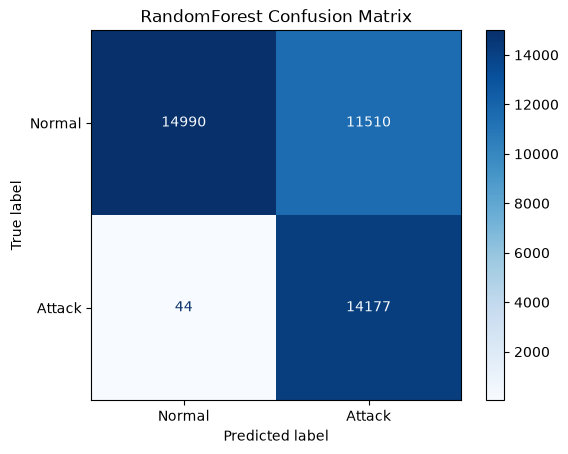

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Normal", "Attack"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("RandomForest Confusion Matrix")
plt.savefig(
    "../results/images/confusion_matrix_rf.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

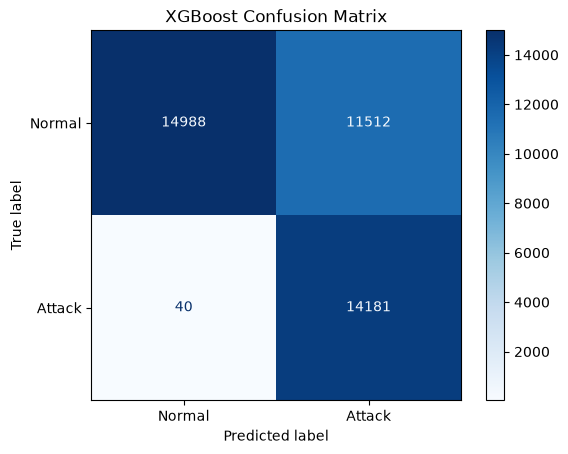

In [23]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["Normal", "Attack"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("XGBoost Confusion Matrix")
plt.savefig(
    "../results/images/confusion_matrix_xgb.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

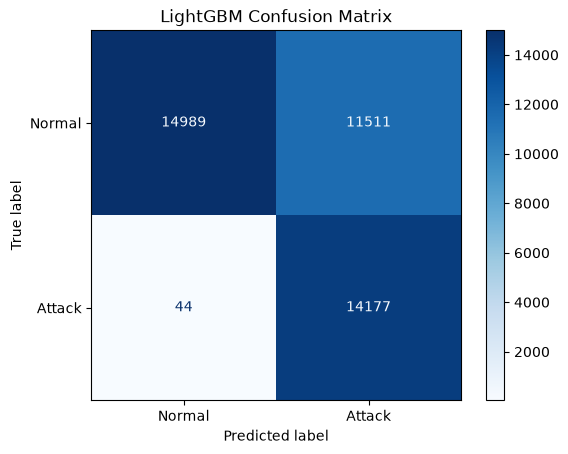

In [24]:
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lgbm,
    display_labels=["Normal", "Attack"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("LightGBM Confusion Matrix")
plt.savefig(
    "../results/images/confusion_matrix_lgbm.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

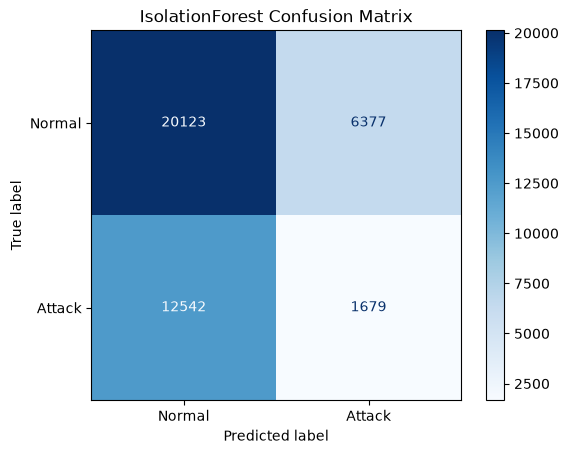

In [25]:
cm_iso = confusion_matrix(y_test, y_pred_iso)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_iso,
    display_labels=["Normal", "Attack"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("IsolationForest Confusion Matrix")
plt.savefig(
    "../results/images/confusion_matrix_iso.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 9. Feature Importance

In [20]:
feature_importance_rf = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance_rf

,Feature,Importance
0,FQDN_count,0.324400
1,subdomain_length,0.236994
4,special,0.214456
5,labels,0.097209
2,numeric,0.057963
7,labels_average,0.033817
8,len,0.016252
3,entropy,0.011782
6,labels_max,0.007128


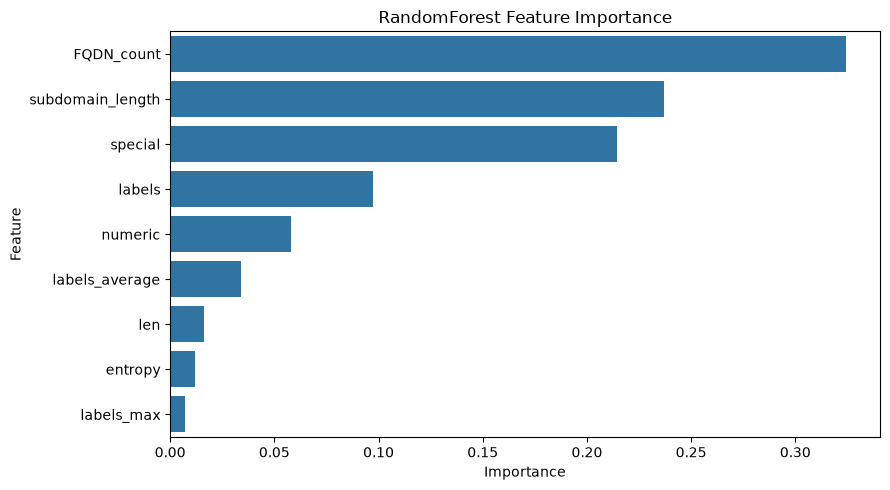

In [26]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=feature_importance_rf,
    x="Importance",
    y="Feature"
)

ax.set_title("RandomForest Feature Importance")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig(
    "../results/images/feature_importance_rf.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 10. 최종 해석

- RandomForest, XGBoost, LightGBM은 현재 대표 정상 DNS 데이터와 Heavy Text 공격 데이터 비교에서 매우 유사한 성능을 보였다.
- 세 지도학습 모델 모두 공격 Recall이 약 0.997로 매우 높아 테스트 데이터의 공격 샘플 대부분을 탐지하였다.
- 반면 Precision은 약 0.552 수준으로, 정상 DNS를 공격으로 잘못 판단하는 False Positive가 많이 발생하였다.
- Confusion Matrix에서도 실제 공격을 놓치는 경우는 적었지만, 정상 트래픽 중 상당수가 공격으로 분류되는 문제가 확인되었다.
- 따라서 현재 모델은 공격 탐지 민감도는 높지만, 실제 관제 환경에 적용하기 위해서는 False Positive를 줄이는 추가 개선이 필요하다.
- IsolationForest는 라벨을 사용하지 않는 비지도 이상탐지 방식으로 학습되었으며, 현재 설정에서는 지도학습 모델보다 낮은 공격 탐지 성능을 보였다.
- IsolationForest 결과는 지도학습 모델과 동일한 목적의 분류 성능으로만 해석하기보다, 향후 라벨이 없는 이상행동 탐지를 위한 보조 접근법으로 추가 검증할 필요가 있다.
- RandomForest Feature Importance에서는 `FQDN_count`, `subdomain_length`, `special` 순으로 상대적으로 높은 중요도를 보였다.
- EDA에서 확인한 주요 Feature 후보 중 일부가 RandomForest에서도 높은 중요도를 보여, EDA에서 발견한 패턴이 모델링 결과와 일부 연결되는 것을 확인하였다.
- 다만 현재 모델링은 대표 정상 데이터와 Heavy Text 공격을 중심으로 수행했기 때문에, 전체 공격 유형에 대한 성능으로 일반화해서는 안 된다.

Feature Importance

In [22]:
model_comparison.to_csv(
    "../results/model_comparison.csv",
    index=False
)

feature_importance_rf.to_csv(
    "../results/feature_importance.csv",
    index=False
)

print("CSV 저장 완료")

CSV 저장 완료
